# GVH Diagonal Cubic — RACC-C.4-real.2.14
## GW150914 H1/L1 — Realistic Injection Estimator Qualification Audit

**Auteur :** Charlemagne O Laurince  
**Étape :** `RACC-C.4-real.2.14`  
**Noyau GVH Diagonal modifié : NON**

### Entrée méthodologique verrouillée

`real.2.13` a établi, sur son benchmark synthétique contrôlé :

\[
\boxed{\texttt{HIERARCHY-CONVERGED-MODERATE-SIGMA}}
\]

avec `phase_slope` comme meilleur estimateur **sur ce benchmark précis**, sans validation physique du retard H1↔L1.

### Question de real.2.14

Le classement de `real.2.13` survit-il lorsqu'on remplace le bruit blanc + chirp simple par :

\[
\boxed{\text{waveform GR IMRPhenomD}+\text{bruit réel off-source H1/L1}+\text{retard injecté connu}}
\]

et lorsqu'on impose un contrôle de phase explicitement invariant modulo \(2\pi\) ?

Estimateurs comparés : `xcorr`, `GCC-PHAT`, `phase_slope_unwrap`, `phase_circular_2pi_safe`, plus `matched_template_oracle` comme contrôle supérieur utilisant le template exact injecté.

### Retards injectés

\[
\tau_{\rm inj}\in\{-10,-7,-4,-1,0,+1,+4,+7,+10\}\ {\rm ms}.
\]

### Gates pré-enregistrés de qualification méthodologique

Un estimateur candidat est `QUALIFIED` uniquement si :

\[
|\mathrm{median\ bias}|\le0.5\ {\rm ms},\quad
\sigma_{\rm robust}=1.4826\,\mathrm{MAD}(e)\le1.5\ {\rm ms},
\]

\[
P(|e|\le2\ {\rm ms})\ge0.80,\qquad P_{90}(|e|)\le3\ {\rm ms}.
\]

### Stop-rule

Même si un estimateur est qualifié :

\[
\boxed{\texttt{TIMING-VALIDATED=False},\quad D_T^{ref}=\texttt{NOT-AUTHORIZED},\quad \texttt{REAL3-AUTHORIZED=False}}
\]


In [1]:
import os, sys, subprocess, importlib, json
from pathlib import Path

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import lal, lalsimulation as lalsim, lalframe
except Exception:
    pip_install("lalsuite"); importlib.invalidate_caches()
    import lal, lalsimulation as lalsim, lalframe

try:
    import gwpy
except Exception:
    pip_install("gwpy"); importlib.invalidate_caches(); import gwpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from gwpy.timeseries import TimeSeries

RNG=np.random.default_rng(214)
print("gwpy:",gwpy.__version__)
print("lalsimulation:",hasattr(lalsim,"SimInspiralChooseFDWaveform"))

/tmp/ipykernel_2563/3061469412.py:11: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal, lalsimulation as lalsim, lalframe


gwpy: 4.0.1
lalsimulation: True


## 1 — Chargement des données réelles H1/L1

In [2]:
GPS_EVENT=1126259462.0
FS_EXPECTED=4096.0

def discover(pattern):
    roots=[Path.cwd(),Path("/content"),Path("/content/drive/MyDrive"),Path("/mnt/data")]
    hits=[]
    for root in roots:
        if not root.exists(): continue
        for d in [root,root/"data"/"GW150914",root/"gvh_diagonal_cubic"/"data"/"GW150914"]:
            if d.exists(): hits += list(d.glob(pattern))
    return hits[0].resolve() if hits else None

H1=discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
L1=discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")
if H1 is None or L1 is None:
    try:
        from google.colab import files
        files.upload()
        H1=discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
        L1=discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")
    except Exception: pass
if H1 is None or L1 is None: raise FileNotFoundError("Fichiers LOSC H1/L1 GW150914 introuvables.")

h1_ts=TimeSeries.read(str(H1),channel="H1:LOSC-STRAIN")
l1_ts=TimeSeries.read(str(L1),channel="L1:LOSC-STRAIN")
h1=np.asarray(h1_ts.value,float); l1=np.asarray(l1_ts.value,float)
fs=float(h1_ts.sample_rate.value); gps0=float(h1_ts.t0.value)
t_rel=gps0+np.arange(len(h1))/fs-GPS_EVENT
assert np.isclose(fs,FS_EXPECTED) and len(h1)==len(l1)==131072
print(H1.name); print(L1.name); print("N =",len(h1),"fs =",fs)

Saving H-H1_LOSC_4_V2-1126259446-32 2.gwf to H-H1_LOSC_4_V2-1126259446-32 2.gwf
Saving L-L1_LOSC_4_V2-1126259446-32.gwf to L-L1_LOSC_4_V2-1126259446-32.gwf
H-H1_LOSC_4_V2-1126259446-32 2.gwf
L-L1_LOSC_4_V2-1126259446-32.gwf
N = 131072 fs = 4096.0


## 2 — Prétraitement fixe de qualification

In [3]:
def center(x):
    x=np.asarray(x,float); return x-np.mean(x)

def band_notch(x,lo=35.0,hi=350.0):
    sos=signal.butter(4,[lo,hi],btype="bandpass",fs=fs,output="sos")
    y=signal.sosfiltfilt(sos,center(x))
    for f0 in [60,120,180,240,300]:
        b,a=signal.iirnotch(f0,Q=30,fs=fs); y=signal.filtfilt(b,a,y)
    return y

h1_f=band_notch(h1); l1_f=band_notch(l1)

## 3 — Génération d’un waveform GR IMRPhenomD

template samples: 8192 duration: 2.0


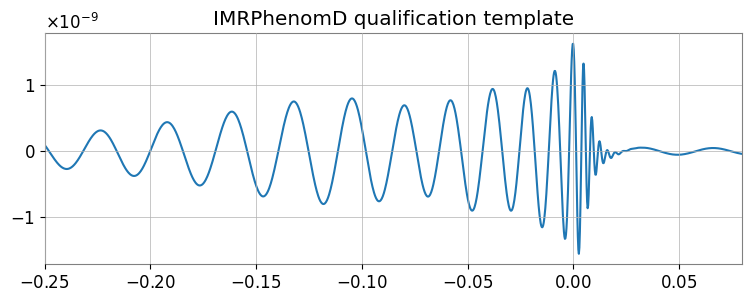

In [4]:
MSUN_SI=lal.MSUN_SI; PC_SI=lal.PC_SI

def make_imrphenomd_template(fs=4096.0,duration=2.0,m1_msun=36.0,m2_msun=29.0,distance_mpc=410.0,inclination=0.7,f_min=30.0):
    n=int(2**np.ceil(np.log2(int(round(duration*fs)))))
    duration=n/fs; delta_f=1.0/duration; f_max=fs/2
    hp,hc=lalsim.SimInspiralChooseFDWaveform(
        m1_msun*MSUN_SI,m2_msun*MSUN_SI,0,0,0,0,0,0,
        distance_mpc*1e6*PC_SI,inclination,0.0,0.0,0.0,0.0,
        delta_f,f_min,f_max,f_min,None,lalsim.IMRPhenomD)
    H=np.asarray(hp.data.data,complex); target=n//2+1
    H=np.pad(H,(0,max(0,target-len(H))))[:target]
    h=np.fft.irfft(H,n=n)
    peak=int(np.argmax(np.abs(h))); h=np.roll(h,n//2-peak)
    h*=signal.windows.tukey(n,alpha=.10); h=center(h)
    h/=np.sqrt(np.mean(h*h))+np.finfo(float).eps
    return h

template=make_imrphenomd_template()
print("template samples:",len(template),"duration:",len(template)/fs)
tt=(np.arange(len(template))-len(template)//2)/fs
plt.figure(figsize=(9,3)); plt.plot(tt,template); plt.xlim(-.25,.08); plt.grid(True); plt.title("IMRPhenomD qualification template"); plt.show()

## 4 — Injection sans wrap et convention de retard

In [5]:
def fractional_delay(x,delay_s):
    x=np.asarray(x,float); n=len(x); pad=n
    xp=np.pad(x,(pad,pad)); N=len(xp)
    f=np.fft.rfftfreq(N,1/fs); X=np.fft.rfft(xp)
    Y=X*np.exp(-1j*2*np.pi*f*delay_s)
    yp=np.fft.irfft(Y,n=N)
    return yp[pad:pad+n]

imp=np.zeros(4096); imp[2048]=1.0
test=fractional_delay(imp,.003)
measured=(np.argmax(test)-np.argmax(imp))/fs
print("delay convention check [ms]:",measured*1e3)
assert abs(measured-.003)<1/fs

delay convention check [ms]: 2.9296875


## 5 — Fenêtres off-source réelles

In [6]:
SEG_DUR=2.0; NSEG=int(SEG_DUR*fs)
CENTERS=[-12.0,-9.0,-6.0,-3.0,3.0,6.0,9.0,12.0]

def segment_around(x,center_s,duration=SEG_DUR):
    c=int(np.argmin(np.abs(t_rel-center_s))); n=int(duration*fs)
    a=c-n//2; b=a+n
    if a<0 or b>len(x): return None
    return np.array(x[a:b],float)

noise_pairs=[]
for c in CENTERS:
    nh=segment_around(h1_f,c); nl=segment_around(l1_f,c)
    if nh is not None and nl is not None and len(nh)==NSEG and len(nl)==NSEG:
        noise_pairs.append((c,nh,nl))
print("off-source pairs:",len(noise_pairs)); assert len(noise_pairs)>=6

off-source pairs: 8


## 6 — Estimateurs

In [7]:
MAX_LAG=.012

def parab(a,b,c):
    d=a-2*b+c
    return 0.0 if d==0 or not np.isfinite(d) else .5*(a-c)/d

def xcorr_lag(a,b):
    a=center(a); b=center(b)
    c=signal.correlate(a,b,mode="full",method="fft")
    lag=signal.correlation_lags(len(a),len(b),mode="full")/fs
    m=np.abs(lag)<=MAX_LAG; c=c[m]; lag=lag[m]
    s=np.abs(c); i=int(np.argmax(s))
    frac=parab(s[i-1],s[i],s[i+1]) if 0<i<len(s)-1 else 0.0
    return float(-(lag[i]+frac/fs))

def phat_lag(a,b):
    a=center(a); b=center(b); n=int(2**np.ceil(np.log2(len(a)+len(b))))
    A=np.fft.rfft(a,n=n); B=np.fft.rfft(b,n=n); G=A*np.conj(B)
    R=G/(np.abs(G)+np.finfo(float).eps)
    cc=np.fft.irfft(R,n=n); cc=np.concatenate((cc[-n//2:],cc[:n//2]))
    lag=np.arange(-n//2,n//2)/fs; m=np.abs(lag)<=MAX_LAG
    s=np.abs(cc[m]); ll=lag[m]; i=int(np.argmax(s))
    frac=parab(s[i-1],s[i],s[i+1]) if 0<i<len(s)-1 else 0.0
    return float(-(ll[i]+frac/fs))

def phase_objects(a,b,nper=512):
    f,Pxy=signal.csd(a,b,fs=fs,nperseg=nper,noverlap=nper//2,window="hann")
    _,coh=signal.coherence(a,b,fs=fs,nperseg=nper,noverlap=nper//2,window="hann")
    ph=np.angle(Pxy); m=(f>=40)&(f<=300)&np.isfinite(ph)&np.isfinite(coh)
    return f[m],ph[m],coh[m]

def phase_slope_unwrap(a,b):
    f,ph,coh=phase_objects(a,b); m=coh>=.10
    f=f[m]; ph=ph[m]; w=coh[m]
    if len(f)<5: return np.nan
    pu=np.unwrap(ph); A=np.c_[f,np.ones_like(f)]; W=np.sqrt(np.clip(w,1e-12,None))
    beta,*_=np.linalg.lstsq(A*W[:,None],pu*W,rcond=None)
    return float(beta[0]/(2*np.pi))

def phase_circular_2pi_safe(a,b):
    f,ph,coh=phase_objects(a,b); m=coh>=.10
    f=f[m]; ph=ph[m]; w=coh[m]
    if len(f)<5: return np.nan
    grid=np.linspace(-MAX_LAG,MAX_LAG,2401); z=np.exp(1j*ph)
    score=np.empty_like(grid)
    for i,tau in enumerate(grid): score[i]=np.abs(np.sum(w*z*np.exp(-1j*2*np.pi*f*tau)))
    j=int(np.argmax(score)); frac=parab(score[j-1],score[j],score[j+1]) if 0<j<len(score)-1 else 0.0
    return float(grid[j]+frac*(grid[1]-grid[0]))

def matched_template_oracle_lag(a,b,temp):
    def arrival(x):
        c=signal.correlate(center(x),center(temp),mode="same",method="fft")
        s=np.abs(c); i=int(np.argmax(s)); frac=parab(s[i-1],s[i],s[i+1]) if 0<i<len(s)-1 else 0.0
        return (i+frac)/fs
    return float(arrival(b)-arrival(a))

## 7 — Matrice d’injections réalistes

In [8]:
DELAYS_MS=np.array([-10,-7,-4,-1,0,1,4,7,10],float)
SNR_SCALES=[2.5,4.0,6.0]
rows=[]

temp=template.copy()
if len(temp)>NSEG:
    mid=len(temp)//2; temp=temp[mid-NSEG//2:mid+NSEG//2]
elif len(temp)<NSEG:
    temp=np.pad(temp,(0,NSEG-len(temp)))
temp=np.roll(temp,NSEG//2-int(np.argmax(np.abs(temp))))
temp*=signal.windows.tukey(len(temp),alpha=.08); temp=center(temp); temp/=np.std(temp)+np.finfo(float).eps

for center_s,nh,nl in noise_pairs:
    stdh=np.std(nh)
    for snr_scale in SNR_SCALES:
        Ah=snr_scale*stdh
        response_ratio=float(RNG.uniform(.65,1.35)); polarity=float(RNG.choice([-1.0,1.0]))
        hsig=Ah*temp
        for delay_ms in DELAYS_MS:
            tau=delay_ms*1e-3
            lsig=polarity*response_ratio*Ah*fractional_delay(temp,tau)
            H=nh+hsig; L=nl+lsig
            estimates={
                "xcorr":xcorr_lag(H,L),
                "GCC-PHAT":phat_lag(H,L),
                "phase_slope_unwrap":phase_slope_unwrap(H,L),
                "phase_circular_2pi_safe":phase_circular_2pi_safe(H,L),
                "matched_template_oracle":matched_template_oracle_lag(H,L,temp)}
            for est,val in estimates.items():
                rows.append({"noise_center_s":center_s,"snr_scale":snr_scale,"response_ratio":response_ratio,"polarity":polarity,"delay_injected_ms":delay_ms,"estimator":est,"delay_estimated_ms":val*1e3 if np.isfinite(val) else np.nan,"error_ms":val*1e3-delay_ms if np.isfinite(val) else np.nan})

inj_df=pd.DataFrame(rows); print("rows:",len(inj_df)); display(inj_df.head())

rows: 1080


,noise_center_s,snr_scale,response_ratio,polarity,delay_injected_ms,estimator,delay_estimated_ms,error_ms
0,-12.0,2.5,0.716154,-1.0,-10.0,xcorr,-10.008011,-0.008011
1,-12.0,2.5,0.716154,-1.0,-10.0,GCC-PHAT,-10.008011,-0.008011
2,-12.0,2.5,0.716154,-1.0,-10.0,phase_slope_unwrap,10.029344,20.029344
3,-12.0,2.5,0.716154,-1.0,-10.0,phase_circular_2pi_safe,10.029346,20.029346
4,-12.0,2.5,0.716154,-1.0,-10.0,matched_template_oracle,-10.011362,-0.011362


## 8 — Calibration globale par estimateur

In [9]:
def robust_sigma(x):
    x=np.asarray(x,float); med=np.nanmedian(x)
    return float(1.4826*np.nanmedian(np.abs(x-med)))

summary=[]
for est,d in inj_df.groupby("estimator"):
    e=d.error_ms.to_numpy(float); e=e[np.isfinite(e)]
    summary.append({"estimator":est,"n_eff":int(len(e)),"median_bias_ms":float(np.median(e)),"mean_bias_ms":float(np.mean(e)),"robust_sigma_ms":robust_sigma(e),"rmse_ms":float(np.sqrt(np.mean(e**2))),"p90_abs_error_ms":float(np.percentile(np.abs(e),90)),"success_abs2ms":float(np.mean(np.abs(e)<=2.0)),"success_abs1ms":float(np.mean(np.abs(e)<=1.0))})
summary_df=pd.DataFrame(summary).sort_values("rmse_ms"); display(summary_df)

,estimator,n_eff,median_bias_ms,mean_bias_ms,robust_sigma_ms,rmse_ms,p90_abs_error_ms,success_abs2ms,success_abs1ms
0,GCC-PHAT,216,0.001028,0.001707,0.015179,0.023488,0.038417,1.000000,1.000000
4,xcorr,216,0.001028,0.001707,0.015179,0.023488,0.038417,1.000000,1.000000
1,matched_template_oracle,216,0.000341,0.002679,0.013910,0.023624,0.039941,1.000000,1.000000
2,phase_circular_2pi_safe,216,-0.002835,0.000367,11.878372,12.155651,20.014091,0.222222,0.111111
3,phase_slope_unwrap,216,-0.002835,0.000368,11.878375,12.155654,20.014111,0.222222,0.111111


## 9 — Performance par niveau d’injection

In [10]:
snr_rows=[]
for (est,snr),d in inj_df.groupby(["estimator","snr_scale"]):
    e=d.error_ms.to_numpy(float); e=e[np.isfinite(e)]
    snr_rows.append({"estimator":est,"snr_scale":snr,"n_eff":len(e),"bias_ms":float(np.median(e)),"robust_sigma_ms":robust_sigma(e),"p90_abs_error_ms":float(np.percentile(np.abs(e),90)),"success_abs2ms":float(np.mean(np.abs(e)<=2.0))})
snr_df=pd.DataFrame(snr_rows); display(snr_df)

,estimator,snr_scale,n_eff,bias_ms,robust_sigma_ms,p90_abs_error_ms,success_abs2ms
0,GCC-PHAT,2.5,72,0.001373,0.030023,0.059900,1.000000
1,GCC-PHAT,4.0,72,0.001072,0.012729,0.031084,1.000000
2,GCC-PHAT,6.0,72,0.000498,0.008597,0.023444,1.000000
3,matched_template_oracle,2.5,72,0.002463,0.025173,0.060616,1.000000
4,matched_template_oracle,4.0,72,-0.000017,0.012092,0.030676,1.000000
5,matched_template_oracle,6.0,72,0.000592,0.009127,0.023181,1.000000
6,phase_circular_2pi_safe,2.5,72,-0.005192,11.880477,20.016440,0.236111
7,phase_circular_2pi_safe,4.0,72,0.000004,11.878061,20.014173,0.222222
8,phase_circular_2pi_safe,6.0,72,-0.001913,11.876673,20.012656,0.208333
9,phase_slope_unwrap,2.5,72,-0.005246,11.880480,20.016439,0.236111


## 10 — Symétrie en signe du retard

In [11]:
sign_rows=[]
for est,d in inj_df.groupby("estimator"):
    neg=d[d.delay_injected_ms<0].error_ms.dropna().to_numpy(float); pos=d[d.delay_injected_ms>0].error_ms.dropna().to_numpy(float)
    sign_rows.append({"estimator":est,"median_error_negative_ms":float(np.median(neg)) if len(neg) else np.nan,"median_error_positive_ms":float(np.median(pos)) if len(pos) else np.nan,"sign_bias_gap_ms":float(abs(np.median(pos)-np.median(neg))) if len(pos) and len(neg) else np.nan})
sign_df=pd.DataFrame(sign_rows); display(sign_df)

,estimator,median_error_negative_ms,median_error_positive_ms,sign_bias_gap_ms
0,GCC-PHAT,0.001088,0.000783,0.000305
1,matched_template_oracle,-0.000656,0.001271,0.001927
2,phase_circular_2pi_safe,11.005930,-10.999310,22.005240
3,phase_slope_unwrap,11.005931,-10.999311,22.005242
4,xcorr,0.001088,0.000783,0.000305


## 11 — Courbe estimé versus injecté

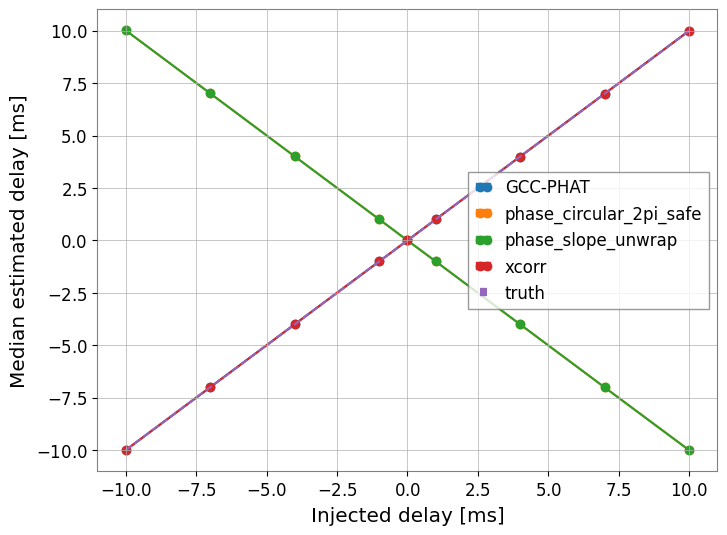

In [12]:
plot_df=inj_df[inj_df.estimator!="matched_template_oracle"]
plt.figure(figsize=(8,6))
for est,d in plot_df.groupby("estimator"):
    g=d.groupby("delay_injected_ms").delay_estimated_ms.median(); plt.plot(g.index,g.values,marker="o",label=est)
plt.plot(DELAYS_MS,DELAYS_MS,"--",label="truth"); plt.xlabel("Injected delay [ms]"); plt.ylabel("Median estimated delay [ms]"); plt.grid(True); plt.legend(); plt.show()

## 12 — Qualification pré-enregistrée

In [13]:
QUAL_THRESH={"abs_median_bias_ms":.5,"robust_sigma_ms":1.5,"success_abs2ms":.80,"p90_abs_error_ms":3.0}
qual_rows=[]
for _,r in summary_df.iterrows():
    if r.estimator=="matched_template_oracle": continue
    qualified=bool(abs(r.median_bias_ms)<=.5 and r.robust_sigma_ms<=1.5 and r.success_abs2ms>=.80 and r.p90_abs_error_ms<=3.0)
    qual_rows.append({"estimator":r.estimator,"qualified":qualified,"abs_median_bias_ms":abs(r.median_bias_ms),"robust_sigma_ms":r.robust_sigma_ms,"success_abs2ms":r.success_abs2ms,"p90_abs_error_ms":r.p90_abs_error_ms,"rmse_ms":r.rmse_ms})
qual_df=pd.DataFrame(qual_rows).sort_values(["qualified","rmse_ms"],ascending=[False,True]); display(qual_df)

,estimator,qualified,abs_median_bias_ms,robust_sigma_ms,success_abs2ms,p90_abs_error_ms,rmse_ms
0,GCC-PHAT,True,0.001028,0.015179,1.000000,0.038417,0.023488
1,xcorr,True,0.001028,0.015179,1.000000,0.038417,0.023488
2,phase_circular_2pi_safe,False,0.002835,11.878372,0.222222,20.014091,12.155651
3,phase_slope_unwrap,False,0.002835,11.878375,0.222222,20.014111,12.155654


## 13 — Verdict automatique

In [14]:
qualified=qual_df[qual_df.qualified==True].copy()
if len(qualified):
    WINNER=str(qualified.iloc[0].estimator); FINAL_STATUS="ESTIMATOR-QUALIFIED-ON-REALISTIC-INJECTIONS"
else:
    WINNER=str(qual_df.iloc[0].estimator) if len(qual_df) else None; FINAL_STATUS="NO-ESTIMATOR-PASSES-QUALIFICATION-GATE"
oracle=summary_df[summary_df.estimator=="matched_template_oracle"]
artifact={"step":"RACC-C.4-real.2.14","event_context":"GW150914 H1/L1 off-source real noise","waveform":"IMRPhenomD","delay_grid_ms":DELAYS_MS.tolist(),"snr_scales":SNR_SCALES,"n_noise_pairs":len(noise_pairs),"qualification_thresholds":QUAL_THRESH,"winner_methodological":WINNER,"final_status":FINAL_STATUS,"oracle_control":oracle.iloc[0].to_dict() if len(oracle) else {},"TIMING_VALIDATED":False,"D_T_ref":"NOT-AUTHORIZED","REAL3_AUTHORIZED":False,"DISPERSION_READY_modified":False,"HH_chain_modified":False,"core_GVH_modified":False}
print(json.dumps(artifact,indent=2,default=float))

{
  "step": "RACC-C.4-real.2.14",
  "event_context": "GW150914 H1/L1 off-source real noise",
  "waveform": "IMRPhenomD",
  "delay_grid_ms": [
    -10.0,
    -7.0,
    -4.0,
    -1.0,
    0.0,
    1.0,
    4.0,
    7.0,
    10.0
  ],
  "snr_scales": [
    2.5,
    4.0,
    6.0
  ],
  "n_noise_pairs": 8,
  "qualification_thresholds": {
    "abs_median_bias_ms": 0.5,
    "robust_sigma_ms": 1.5,
    "success_abs2ms": 0.8,
    "p90_abs_error_ms": 3.0
  },
  "winner_methodological": "GCC-PHAT",
  "final_status": "ESTIMATOR-QUALIFIED-ON-REALISTIC-INJECTIONS",
  "oracle_control": {
    "estimator": "matched_template_oracle",
    "n_eff": 216,
    "median_bias_ms": 0.00034129215415168446,
    "mean_bias_ms": 0.002679016854176815,
    "robust_sigma_ms": 0.013909634818989053,
    "rmse_ms": 0.023624250088065152,
    "p90_abs_error_ms": 0.03994056258171952,
    "success_abs2ms": 1.0,
    "success_abs1ms": 1.0
  },
  "TIMING_VALIDATED": false,
  "D_T_ref": "NOT-AUTHORIZED",
  "REAL3_AUTHORIZED": fa

## 14 — Interprétation autorisée

Si un estimateur passe, le verdict autorisé est uniquement :

\[
\boxed{\texttt{ESTIMATOR-QUALIFIED-ON-REALISTIC-INJECTIONS}}
\]

Cela signifie que l'estimateur a récupéré des retards **connus** dans du bruit réel H1/L1 avec un waveform GR contrôlé. Cela ne signifie pas que son résultat sur GW150914 réel est déjà physiquement validé.

Si aucun estimateur ne passe :

\[
\boxed{\texttt{NO-ESTIMATOR-PASSES-QUALIFICATION-GATE}}
\]

`matched_template_oracle` utilise volontairement le template exact injecté et ne doit jamais être traité comme un estimateur aveugle équivalent aux autres.

Les gates restent :

\[
\boxed{\texttt{TIMING-VALIDATED=False},\quad D_T^{ref}=\texttt{NOT-AUTHORIZED},\quad \texttt{REAL3-AUTHORIZED=False}}
\]
